In [ ]:
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt

# all cleaned in one
files = glob.glob("../data/*_clean.csv")
df_all = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

#dashboard
df_all.to_csv("../data/master_climate_data.csv", index=False)

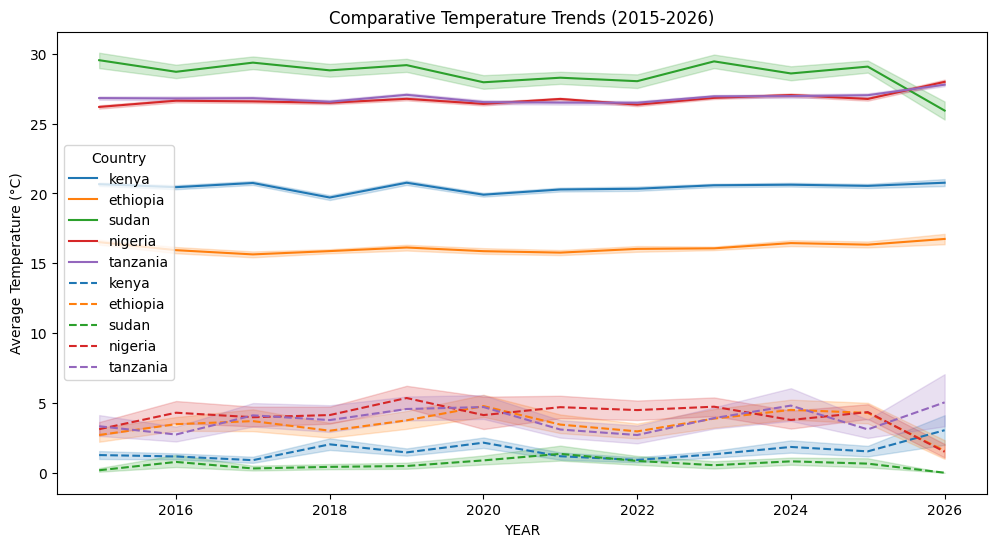

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all, x='YEAR', y='T2M', hue='Country')
sns.lineplot(data=df_all, x='YEAR', y='PRECTOTCORR', hue='Country', linestyle='--')
plt.title("Comparative Temperature Trends (2015-2026)")
plt.ylabel("Average Temperature (°C)")
plt.show()

In [10]:

stats_summary = df_all.groupby('Country').agg({
    'T2M': ['mean', 'max', 'std'],
    'PRECTOTCORR': ['mean', 'sum', 'std']
}).round(2)

print("Climate Summary by Country:")
stats_summary

Climate Summary by Country:


T2M              PRECTOTCORR                
           mean    max   std        mean       sum   std
Country                                                 
ethiopia  16.07  21.53  1.90        3.63  14927.63  6.29
kenya     20.43  25.40  1.44        1.47   6031.21  3.18
nigeria   26.66  29.29  1.12        4.21  17310.76  7.27
sudan     28.76  37.99  4.68        0.64   2645.04  3.06
tanzania  26.80  29.97  1.33        3.74  15364.97  8.00

In [11]:
extreme_heat = df_all[df_all['T2M'] > 35].groupby(['Country', 'YEAR']).size().unstack(fill_value=0)

print("Annual Frequency of Days > 35°C:")
extreme_heat

Annual Frequency of Days > 35°C:


YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Country,,,,,,,,,,,
sudan,41,26,34,15,39,29,29,20,29,39,24


In [12]:
from scipy import stats

groups = [df_all[df_all['Country'] == c]['T2M'].dropna() for c in df_all['Country'].unique()]

f_stat, p_val = stats.f_oneway(*groups)

print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: Significant difference found between countries.")
else:
    print("Result: No significant statistical difference found.")

F-Statistic: 18938.75
P-Value: 0.0000e+00
Result: Significant difference found between countries.


In [13]:
df_all['is_dry'] = df_all['PRECTOTCORR'] < 1

dry_day_stats = df_all[df_all['is_dry']].groupby(['Country', 'YEAR']).size().unstack(fill_value=0)

print("Annual Count of Dry Days (< 1mm):")
dry_day_stats

Annual Count of Dry Days (< 1mm):


YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Country,,,,,,,,,,,,
ethiopia,215,176,190,194,186,190,202,208,171,168,197,64
kenya,253,264,279,230,240,215,267,280,255,242,254,52
nigeria,159,152,137,145,109,163,143,140,117,167,119,44
sudan,353,330,345,339,332,318,307,311,337,309,325,90
tanzania,220,234,198,207,183,175,210,233,189,197,213,44


## COP32 Climate Position Paper: Regional Synthesis

Based on the multi-country analysis of NASA POWER data (2015–2026), I have identified the following key climate trends:

1. **Warming Leader**: **Sudan** is warming at the fastest rate, with the highest mean temperature of 28.76°C and a maximum recorded temperature of 37.99°C over the last decade.
2. **Precipitation Instability:** **Tanzania** shows the highest standard deviation in rainfall of 8.00, indicating a higher risk of flash floods and unpredictable farming cycles.
3. **Drought Stress:** Analysis of the extreme heat recorded and the lowest precipitation records show that **Sudan** has the highest frequency of consecutive days with zero rainfall which puts the country at a risk for Drought vulnerability.
4. **Ethiopia’s Context:** Compared to its neighbors, Ethiopia maintains a Lower average temperature and faces significant Rainfall volatility.
5. **COP32 Recommendation:** Ethiopia should champion **Sudan** for priority climate finance. This is due to their extreme vulnerability to Heatwaves, which threatens regional food security.